# comparing automatic and manual transcriptions of participant audio

In [1]:
import numpy as np
import pandas as pd
import hypertools as hyp
import matplotlib.pyplot as plt
import seaborn as sns
import quail
import pickle
import random
import re
import os
import json
from num2words import num2words
from nltk.corpus import stopwords
from scipy.signal import resample
from scipy.stats import pearsonr, sem
from scipy.spatial.distance import cdist
%matplotlib inline

In [35]:
mandir = '../../../data/transcriptions/manual/'

In [2]:
def _z2r(z):
    """
    Function that calculates the inverse Fisher z-transformation

    Parameters
    ----------
    z : int or ndarray
        Fishers z transformed correlation value

    Returns
    ----------
    result : int or ndarray
        Correlation value

    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)

In [3]:
def _r2z(r):
    """
    Function that calculates the Fisher z-transformation

    Parameters
    ----------
    r : int or ndarray
        Correlation value

    Returns
    ----------
    result : int or ndarray
        Fishers z transformed correlation value

    """
    with np.errstate(invalid='ignore', divide='ignore'):
        return 0.5 * (np.log(1 + r) - np.log(1 - r))

In [4]:
def corr_mean(rs, axis=0):
    """
    Function that calculates the mean of correlation coefficients,
    performing Fisher z-transformation and inverse z-transormation
    
    Parameters
    ----------
    rs: : list or ndarray
        Correlation values
    
    Returns
    ----------
    result : float
        mean of correlation values

    """
    return _z2r(np.nanmean([_r2z(r) for r in rs], axis=axis))

## choose 5 participants at random to compare

In [6]:
# load in participants dict
with open('../../../data/pickles/id_maps.p', 'rb') as file:
    id_maps = pickle.load(file)

# random5 = random.sample(id_maps.keys(), 5)
# print(random5)


# Random 5 chosen:
# ['MD-013119-A-01', 'MD-102218-A-07', 'MD-020119-A-04', 'MD-102218-B-01', 'MD-020119-B-03']

# MD-013119-A-01 did not complete experiment. Replacing with MD-013119-A-02
# MD-020119-B-03 did not complete experiment. Replacing with MD-020119-B-02

In [7]:
random5 = ['MD-013119-A-02', 'MD-102218-A-07', 'MD-020119-A-04', 'MD-102218-B-01', 'MD-020119-B-02']

# get ses1 & ses2 psiturk ids
rand5_turkids = {k: id_maps[k] for k in random5}

### create manual transcription directory structure

In [8]:
# man_dir = os.path.abspath('../../data/transcriptions/manual')
# for subid, runs in id_maps.items():
#     for ses, turkid in runs.items():
#         folder = os.path.join(man_dir, subid, turkid)
#         if not os.path.isdir(folder) and not os.path.isdir(os.path.join(man_dir,'drops',subid)):
#             os.makedirs(folder, exist_ok=True)

## automatic transcription

### create speech context from union of words in annotations

In [9]:
atlep1_df = pd.read_pickle('../../../data/annotations_dfs/atlep1.p')
atlep2_df = pd.read_pickle('../../../data/annotations_dfs/atlep2.p')
arrdev_df = pd.read_pickle('../../../data/annotations_dfs/arrdev.p')

In [10]:
def meets_word_criteria(string):
    """
    Removes words with characters not wanted in auto transcriber speech context
    """
    
    good_word = True
    
    # remove words containing digits
    if any(char.isdigit() for char in string):
        good_word = False
    
    # remove words surrounded by single quotes and possessives (avoid duplicates in nested quotations & possessives)
    if string.startswith("'") or string.endswith("'") or string.endswith("'s"):
        good_word = False
        
    # remove unhelpful simple words
    if len(string) <= 2:
        good_word = False
    
    return good_word

In [11]:
def create_speech_context(df):
    """
    Creates episode-specific speech context from video annotations
    """
    
    # use Narrative details (internal and external), Characters on screen, Speech, Character speaking, and Setting
    word_cols = [df.columns[i] for i in [2,3,4,6,7,9]]
    
    # create single string of all text
    allwords = ' '.join(df.loc[:,word_cols].apply(lambda x: ' '.join(x.dropna()), axis=1).values.tolist())
    
    # remove all characters except spaces (catches \n and \t), letters, apostrophes, dashes
    no_punctuation = re.sub("[^\w\s'-]+", '', allwords)
    
    speech_context = []
    
    # split words into list
    for word in no_punctuation.split():
        # identify unique words that meet criteria
        if word.lower() not in speech_context and meets_word_criteria(word):
            speech_context.append(word.lower())

    # remove English stopwords
    speech_context_nostop = [word for word in speech_context if word not in stopwords.words('english')]
    
    return speech_context_nostop

In [12]:
atlep1_speech_context = create_speech_context(atlep1_df)
atlep2_speech_context = create_speech_context(atlep2_df)
arrdev_speech_context = create_speech_context(arrdev_df)

In [13]:
audiodir = os.path.abspath('../../../data/audio/')
keypath = os.path.abspath('../../../../google-credentials/cloud-speech-credentials.json')

# for sid, data in rand5_turkids.items():
#     print(sid + ':')
#     for ses, turkid in data.items():
        
#         # get corrrect audio file names and speech context by session and condition
#         if ses == 'session 1':
#             audiofiles = [turkid+'-recall.wav', turkid+'-prediction.wav']
#         elif ses == 'session 2':
#             audiofiles = [turkid+'-delayed.wav', turkid+'-recall.wav']

#         for audiofile in audiofiles:
            
#             # SKIP ALREADY FINISHED ONE
#             if audiofile != 'debughKp9W:debug1QFCO-recall.wav':
                
#                 # set correct episode speech context
#                 if session == 'session 2' and audiofile.endswith('-recall.txt'):
#                     if 'A' in sid:
#                         episode_context = atlep2_speech_context
#                     elif 'B' in sid:
#                         episode_context = arrdev_speech_context
#                     else:
#                         episode_context = atlep1_speech_context
            
#                 # find file in correct testroom dir
#                 path = os.path.join(audiodir,'room1',turkid, audiofile)
#                 if not os.path.isfile(path):
#                     path = os.path.join(audiodir,'room2',turkid, audiofile)
#                     if not os.path.isfile(path):
#                         print('AUDIO FILE NOT FOUND: ' + path)
#                         break

#                 # and decode the audio
#                 print('\tdecoding ' + ses + ': ' + audiofile + ' ...')
#                 quail.decode_speech(path=path, keypath=keypath, save=True, speech_context=episode_context,
#                                     enable_word_time_offsets=False)


### parse google cloud objects into text files

In [14]:
def parse_response_object(filepath):
    """
    parses Google Cloud RecognizeResponse objects and returns string of full transcript
    """
    
    # load pickled response object
    with open(filepath, 'rb') as f:
        resp_obj = pickle.load(f)
    
    # list for full participant transcript
    full_transcript = []
    # loop over decoded chunks
    for chunk in resp_obj:
        # access transcript
        for result in chunk.results:
            single_transcript = result.alternatives[0].transcript
            # split to list
            transcript_aslist = [word.lower() for word in single_transcript.split(' ')]

            for i, word in enumerate(transcript_aslist):
                # strip punctuation
                if word.endswith('.') or word.endswith(',') or word.endswith(':'):
                    transcript_aslist[i] = word[:-1]
                        
                # convert digits to words
                if word.isdigit():
                    transcript_aslist[i] = num2words(int(word))
                # convert times to words
                if ':' in word:
                    transcript_aslist[i] = ' '.join([num2words(int(i)) for i in transcript_aslist[i].split(':')])
                # convert currency to words
                if '$' in word:
                    transcript_aslist[i] = num2words(word.strip('$').replace(',',''), to='currency', 
                                                     currency='USD').split(',')[0]

            full_transcript.append(' '.join(transcript_aslist))
            
    
    return ' '.join(full_transcript)

In [15]:
# for sid, data in rand5_turkids.items():
#     for ses, tid in data.items():
        
#         # find file in correct test room
#         path = os.path.join(audiodir,'room1',tid)
#         if not os.path.isdir(path):
#             path = os.path.join(audiodir,'room2',tid)
#             if not os.path.isdir(path):
#                 print('ID not found: ' + tid)
#                 break
        
#         # assign correct audio file types
#         if os.path.isfile(os.path.join(path,tid+'-prediction.wav.p')):
#             files = ['-prediction.wav.p', '-recall.wav.p']
#         else:
#             files = ['-delayed.wav.p', '-recall.wav.p']
        
#         # parse each response object and save out text file
#         for file in files:
#             filepath = os.path.join(path,tid+file)
#             transcript = parse_response_object(filepath)
            
#             with open(filepath.rstrip('.p')+'.txt', 'w') as f:
#                 f.write(transcript)
            

## model transcriptions

### estimate recall window size: how many words were in the average recall window for for the sherlock data?

In [17]:
# path to sherlock recall transcripts
sher_datadir = '../../../../sherlock_behavioral_data/'

# list of tuples: (sub, average recall window length)
subs_window_lengths = []

for sub in range(1,18):
    
    recall = pd.read_csv(sher_datadir+'NN'+str(sub)+' transcript.txt', header=None, sep='.', error_bad_lines=False, encoding='latin-1').values.tolist()[0][:-1]

    rs = []  
    # loop over sentences
    for sentence in recall:
        try:
            s = sentence.encode('utf-8').strip()
            rs.append(sentence)
        except:
            pass # skips over nans
        
    sub_recall_w = []
    for idx, sentence in enumerate(rs):
        # only consider full-sized windows
        if idx + 10 <= len(rs):
            sub_recall_w.append(','.join(rs[idx:idx+10]))
    
    subs_window_lengths.append((sub,np.mean([len(window.split()) for window in sub_recall_w])))


np.mean([nwords[1] for nwords in subs_window_lengths])

206.8387218500201

In [16]:
# model parameters
n_topics = 100
episode_wsize = None
recall_wsize = 200

# vectorizer parameters
vectorizer_params = {
    'model' : 'CountVectorizer', 
    'params' : {
        'stop_words' : 'english'
    }
}

# topic model parameters
semantic_params = {
    'model' : 'LatentDirichletAllocation', 
    'params' : {
        'n_components' : n_topics,
        'learning_method' : 'batch',
        'random_state' : 0,
    }
}

In [17]:
def get_episode_windows(episode_df, episode_wsize):
    # throw all annotations into bag of words to train model
    episode_bag = episode_df.loc[:,'Narrative details (external events)':'Setting'].apply(lambda x: ', '.join(x.fillna('')), axis=1).values.tolist()

    # create list for annotation sliding windows (of size w_size)
    episode_w = []
    for idx, sentence in enumerate(episode_bag):
        episode_w.append(','.join(episode_bag[idx:idx+episode_wsize]))

    return episode_w

In [17]:
# # sliding annotation windows for the three episodes
# atlep1_windows = get_episode_windows(atlep1_df, episode_wsize)
# atlep2_windows = get_episode_windows(atlep2_df, episode_wsize)
# arrdev_windows = get_episode_windows(arrdev_df, episode_wsize)

In [18]:
atlep1_windows = get_episode_windows(atlep1_df, int(round(len(atlep1_df)*0.05)))
atlep2_windows = get_episode_windows(atlep2_df, int(round(len(atlep2_df)*0.05)))
arrdev_windows = get_episode_windows(arrdev_df, int(round(len(arrdev_df)*0.05)))

In [9]:
def transform_recall(transcript, n_topics, recall_wsize, vec_params, sem_params, episode_windows, resample_shape):
    """
    transform recalls based on sliding windows of episode annotations
    """
    # sliding windows of episode annotations and recall words
    recall_w = []

    # split recall transcript into list
    rec_list = transcript.split()
    
    # create overlapping windows of recall_wsize words
    for ix, word in enumerate(rec_list):
        recall_w.append(','.join(rec_list[ix:ix+recall_wsize]))
        
    # create recall model
    recall_model = hyp.tools.format_data(recall_w, vectorizer=vec_params, semantic=sem_params,
                                         corpus=episode_windows)[0]
    
    # return recalled model to corresponding episode model length
    return resample(recall_model, resample_shape)

In [15]:
# empty dict of automatic and manual transcription models for each audio file
rec_models_dict = {}

for sid, data in rand5_turkids.items():
    for ses, tid in data.items():
        if ses == 'session 1':  
            rec_models_dict[tid] = {'recall' : {'automatic' : None, 'manual' : None}, 
                                    'prediction' : {'automatic' : None, 'manual' : None} }
        else:
            rec_models_dict[tid] = {'delayed' : {'automatic' : None, 'manual' : None}, 
                                    'recall' : {'automatic' : None, 'manual' : None} }

In [33]:
# # load in resampled episode models
# models_dir = '../../../data/models/episodes/t100_wProp/trajectories/'
# atlep1_model_prop = np.load(models_dir+'atlep1_model_t100_wProp_res.npy')
# atlep2_model_prop = np.load(models_dir+'atlep2_model_t100_wProp_res.npy')
# arrdev_model_prop = np.load(models_dir+'arrdev_model_t100_wProp_res.npy')

In [28]:
# load in resampled episode models
models_dir = '../../../data/models/episodes/t100_w50/trajectories/'
atlep1_model = np.load(models_dir+'atlep1_model_t100_w50_res.npy')
atlep2_model = np.load(models_dir+'atlep2_model_t100_w50_res.npy')
arrdev_model = np.load(models_dir+'arrdev_model_t100_w50_res.npy')

### compare transcript lengths

In [36]:
autos = []
mans = []
for method in ['automatic', 'manual']:
    for sid, data in rand5_turkids.items():
        for ses, tid in data.items():

            # search in appropriate location for auto/man transcriptions
            if method == 'automatic':
                # find file in correct test room
                path = os.path.join('../../../data/transcriptions/automatic/', sid, tid)
                if not os.path.isdir(path):
                    print('ID not found: ' + tid)
                    break
            else:
                path = os.path.join(mandir,sid,tid)

            # assign correct transcript file types
            if os.path.isfile(os.path.join(path,tid+'-prediction-corrected.wav.txt')) or os.path.isfile(os.path.join(path,tid+'-prediction.txt')):
                files = ['prediction', 'recall']
            elif os.path.isfile(os.path.join(path,tid+'-delayed-corrected.wav.txt')) or os.path.isfile(os.path.join(path,tid+'-delayed.txt')):
                files = ['delayed', 'recall']
            else:
                print('No ' + method + ' transcripts found for subject in ' + path)
                break

            for file in files:

                if method == 'automatic':
                    filepath = os.path.join(path,tid+'-'+file+'-corrected.wav.txt')
                else:
                    filepath = os.path.join(path,tid+'-'+file+'.txt')

                # read in transcript
                with open(filepath, 'r') as f:
                    transcript = f.read()
                if method == 'automatic':
                    autos.append(' '.join([line.split(',')[0].lower() for line in transcript.split('\n')]))
                else:
                    mans.append(transcript)
                    

In [54]:
print('transcript length in words')
print(' auto ', ' man' , '  man/auto')
[(len(autos[ix]), len(mans[ix]), len(mans[ix])/len(autos[ix])) for ix in range(20)]

transcript length in words
 auto   man   man/auto


[(3588, 4283, 1.193701226309922),
 (12814, 19242, 1.5016388325269237),
 (5939, 10796, 1.8178144468765784),
 (5216, 9743, 1.8679064417177915),
 (2826, 3855, 1.3641188959660298),
 (8258, 13333, 1.614555582465488),
 (6840, 11752, 1.7181286549707602),
 (6115, 10312, 1.6863450531479967),
 (2026, 2229, 1.100197433366239),
 (12175, 15238, 1.2515811088295687),
 (7355, 9248, 1.2573759347382734),
 (9075, 10693, 1.1782920110192838),
 (2191, 2872, 1.310816978548608),
 (9798, 14287, 1.4581547254541742),
 (5668, 7772, 1.3712067748764996),
 (6886, 8046, 1.1684577403427243),
 (1087, 1762, 1.6209751609935603),
 (4702, 9893, 2.103998298596342),
 (5374, 11094, 2.0643840714551542),
 (7769, 13973, 1.7985583730209809)]

In [21]:
# for method in ['automatic', 'manual']:
#     for sid, data in rand5_turkids.items():
#         for ses, tid in data.items():

#             # search in appropriate location for auto/man transcriptions
#             if method == 'automatic':
#                 # find file in correct test room
#                 path = os.path.join(audiodir,'room1',tid)
#                 if not os.path.isdir(path):
#                     path = os.path.join(audiodir,'room2',tid)
#                     if not os.path.isdir(path):
#                         print('ID not found: ' + tid)
#                         break
#             else:
#                 path = os.path.join(mandir,sid,tid)

#             # assign correct transcript file types
#             if os.path.isfile(os.path.join(path,tid+'-prediction.wav.txt')) or os.path.isfile(os.path.join(path,tid+'-prediction.txt')):
#                 files = ['prediction', 'recall']
#             elif os.path.isfile(os.path.join(path,tid+'-delayed.wav.txt')) or os.path.isfile(os.path.join(path,tid+'-delayed.txt')):
#                 files = ['delayed', 'recall']
#             else:
#                 print('No ' + method + ' transcripts found for subject in ' + path)
#                 break

#             for file in files:
#                 print('modeling ' + tid + ' ' + file + ', '+ method)
#                 # assign correct annotations dataframe and sliding windows
#                 if ses == 'session 1' or file == 'delayed':
#                     episode_ws = atlep1_windows
#                     resample_shape = np.shape(atlep1_model)[0]
#                 else:
#                     if 'A' in sid:
#                         episode_ws = atlep2_windows
#                         resample_shape = np.shape(atlep2_model)[0]
#                     else:
#                         episode_ws = arrdev_windows
#                         resample_shape = np.shape(arrdev_model)[0]

#                 if method == 'automatic':
#                     filepath = os.path.join(path,tid+'-'+file+'.wav.txt')
#                 else:
#                     filepath = os.path.join(path,tid+'-'+file+'.txt')

#                 # read in transcript
#                 with open(filepath, 'r') as f:
#                     transcript = f.read()

#                 # transform transcript
#                 modeled_transcript = transform_recall(transcript, n_topics, recall_wsize, vectorizer_params, 
#                                               semantic_params, episode_ws, resample_shape)
#                 # add to dictionary
#                 rec_models_dict[tid][file][method] = modeled_transcript


modeling debug5ytRS:debug22nvn prediction, automatic
modeling debug5ytRS:debug22nvn recall, automatic
modeling debug3Z74G:debug6CQ6D delayed, automatic
modeling debug3Z74G:debug6CQ6D recall, automatic
modeling debugWvhTI:debug65Thd prediction, automatic
modeling debugWvhTI:debug65Thd recall, automatic
modeling debugTkyN6:debugdsr6W delayed, automatic
modeling debugTkyN6:debugdsr6W recall, automatic
modeling debugo1MpX:debugfpXYH prediction, automatic
modeling debugo1MpX:debugfpXYH recall, automatic
modeling debugeyj0U:debugsaXvf delayed, automatic
modeling debugeyj0U:debugsaXvf recall, automatic
modeling debugqWZVC:debugZSccI prediction, automatic
modeling debugqWZVC:debugZSccI recall, automatic
modeling debugRvgf2:debugpnybj delayed, automatic
modeling debugRvgf2:debugpnybj recall, automatic
modeling debugAU1cu:debugzdGmZ prediction, automatic
modeling debugAU1cu:debugzdGmZ recall, automatic
modeling debug27k0b:debugOGsyi delayed, automatic
modeling debug27k0b:debugOGsyi recall, autom

In [24]:
# with open('../../../data/pickles/transcription_comparison_models_epwProp_w%s_resampled.p' % str(recall_wsize), 'wb') as file:
#     pickle.dump(rec_models_dict, file)

In [19]:
with open('../../../data/pickles/transcription_comparison_models_w200_resampled.p', 'rb') as file:
    recmod_dict_w200 = pickle.load(file)

In [37]:
with open('../../../data/pickles/transcription_comparison_models_epwProp_w200_resampled.p', 'rb') as file:
    recmod_dict_w200_prop = pickle.load(file)

### hypertools plots of atlep1 immediate & delayed recall trajectories against atlep1 episode trajectory

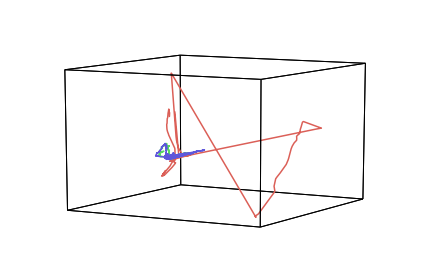

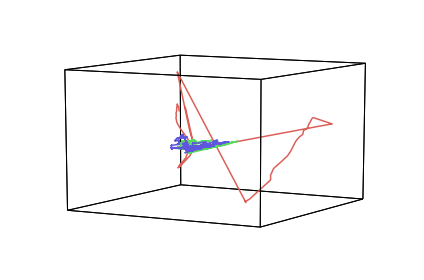

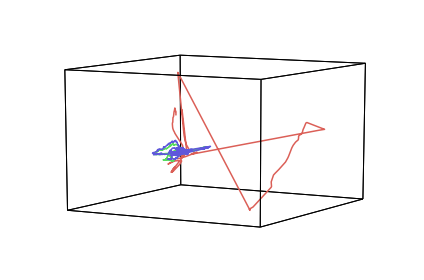

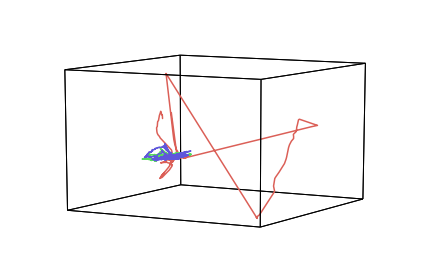

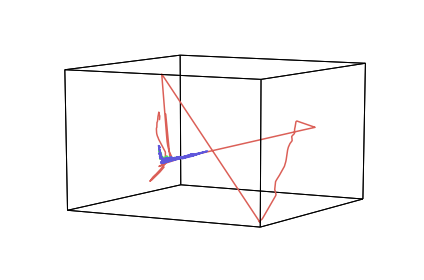

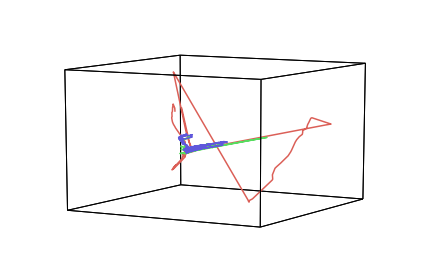

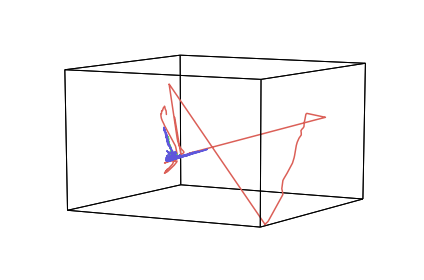

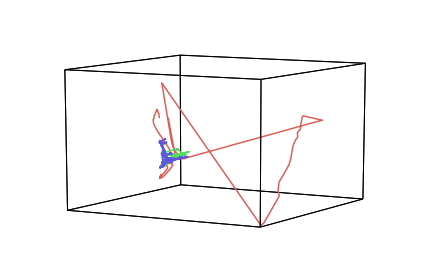

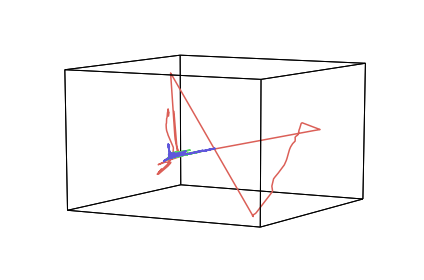

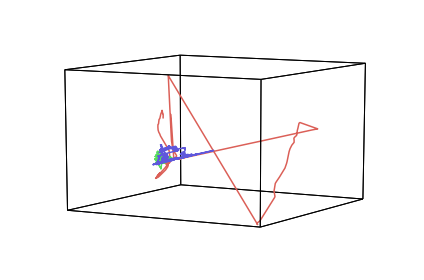

In [39]:
for tid, data in recmod_dict_w200_prop.items():
    for rectype, method in data.items():
        if (rectype == 'recall' and 'delayed' not in data.keys()) or rectype == 'delayed':
            hyp.plot([atlep1_model_prop,method['automatic'],method['manual']])

## evaluate automatic transcription quality

In [20]:
def compare_models(model1, model2):
    return pearsonr(pd.DataFrame(model1).T.corr().values.ravel(), pd.DataFrame(model2).T.corr().values.ravel())[0]

### similarity between auto and manual recall models

In [23]:
atlep1_transc_corrs = []
delayed_transc_corrs = []
atlep2_transc_corrs = []
arrdev_transc_corrs = []
        
for sid, data in rand5_turkids.items():
    for ses, tid in data.items():
        for rectype, transctype in recmod_dict_w200[tid].items():
            if rectype != 'prediction':
                corr = compare_models(transctype['manual'], transctype['automatic'])
                
                if ses == 'session 1':
                    atlep1_transc_corrs.append(corr)
                elif rectype == 'delayed':
                    delayed_transc_corrs.append(corr)
                elif 'A' in sid:
                    atlep2_transc_corrs.append(corr)
                else:
                    arrdev_transc_corrs.append(corr)
                    
print('AVERAGE AUTO-MANUAL TRANSCRIPTION MODEL CORRRELATION:\n______________')
print('Atlep1 (immediate):')
print('\t'+str(corr_mean(atlep1_transc_corrs))+' SEM: '+str(sem(atlep1_transc_corrs)))
print('\n')
print('Atlep1 (delayed):')
print('\t'+str(corr_mean(delayed_transc_corrs))+' SEM: '+str(sem(delayed_transc_corrs)))
print('\n')
print('Atlep2:')
print('\t'+str(corr_mean(atlep2_transc_corrs))+' SEM: '+str(sem(atlep2_transc_corrs)))
print('\n')
print('Arrdev:')
print('\t'+str(corr_mean(arrdev_transc_corrs))+' SEM: '+str(sem(arrdev_transc_corrs)))

AVERAGE AUTO-MANUAL TRANSCRIPTION MODEL CORRRELATION:
______________
Atlep1 (immediate):
	0.6512783975731059 SEM: 0.012640551022842852


Atlep1 (delayed):
	0.634643752760483 SEM: 0.04161830925844536


Atlep2:
	0.5232170436621547 SEM: 0.07997860116023953


Arrdev:
	0.7162412258716035 SEM: 0.09333885640348759


In [36]:
np.mean([0.012640551022842852, 0.04161830925844536, 0.07997860116023953, 0.09333885640348759])

0.05689407946125383

In [26]:
corr_mean(atlep1_transc_corrs+delayed_transc_corrs+atlep2_transc_corrs+arrdev_transc_corrs)

0.6321722004035987

### compare episode model - recall model similarity

In [29]:
# lists of correlations between auto/man transcription-based recall models and respective episode
atlep1_rec_auto = []
atlep1_rec_man = []
delayed_rec_auto = []
delayed_rec_man = []
atlep2_rec_auto = []
atlep2_rec_man = []
arrdev_rec_auto = []
arrdev_rec_man = []


for sid, data in rand5_turkids.items():
    for ses, tid in data.items():
        for rectype, transctype in recmod_dict_w200[tid].items():
            if rectype != 'prediction':
                
                if ses == 'session 1':
                    atlep1_rec_auto.append(compare_models(atlep1_model,transctype['automatic']))
                    atlep1_rec_man.append(compare_models(atlep1_model,transctype['manual']))
                    
                elif rectype == 'delayed':
                    delayed_rec_auto.append(compare_models(atlep1_model,transctype['automatic']))
                    delayed_rec_man.append(compare_models(atlep1_model,transctype['manual']))
                    
                elif 'A' in sid:
                    atlep2_rec_auto.append(compare_models(atlep2_model,transctype['automatic']))
                    atlep2_rec_man.append(compare_models(atlep2_model,transctype['manual']))
                    
                else:
                    arrdev_rec_auto.append(compare_models(arrdev_model,transctype['automatic']))
                    arrdev_rec_man.append(compare_models(arrdev_model,transctype['manual']))
                    
print('AVERAGE EPISODE-RECALL CORRELATIONS\n___________________')                    
print('Atlep1 (immediate):')
print('\tManual: '+str(np.mean(atlep1_rec_man))+', SEM: '+str(sem(atlep1_rec_man)))
print('\tAutomatic: '+str(np.mean(atlep1_rec_auto))+', SEM: '+str(sem(atlep1_rec_auto)))
print('\n')
print('Atlep1 (delayed):')
print('\tManual: '+str(np.mean(delayed_rec_man))+', SEM: '+str(sem(delayed_rec_man)))
print('\tAutomatic: '+str(np.mean(delayed_rec_auto))+', SEM: '+str(sem(delayed_rec_auto)))
print('\n')
print('Atlep2:')
print('\tManual: '+str(np.mean(atlep2_rec_man))+', SEM: '+str(sem(atlep2_rec_man)))
print('\tAutomatic: '+str(np.mean(atlep2_rec_auto))+', SEM: '+str(sem(atlep2_rec_auto)))
print('\n')
print('Arrdev:')
print('\tManual: '+str(np.mean(arrdev_rec_man))+', SEM: '+str(sem(arrdev_rec_man)))
print('\tAutomatic: '+str(np.mean(arrdev_rec_auto))+', SEM: '+str(sem(arrdev_rec_auto)))

AVERAGE EPISODE-RECALL CORRELATIONS
___________________
Atlep1 (immediate):
	Manual: 0.5834108458430476, SEM: 0.03711738483424139
	Automatic: 0.6395997998226446, SEM: 0.02556117815440956


Atlep1 (delayed):
	Manual: 0.6568344026428226, SEM: 0.03053864618398092
	Automatic: 0.6793779250038996, SEM: 0.028161326738754013


Atlep2:
	Manual: 0.599794508375962, SEM: 0.02189537049290873
	Automatic: 0.5857163413990385, SEM: 0.052557735667659866


Arrdev:
	Manual: 0.6723780231375265, SEM: 0.00642980479434091
	Automatic: 0.6635756272616367, SEM: 0.02666501335640853


In [37]:
np.mean([(0.5834108458430476-0.6395997998226446)/0.5834108458430476, 
         (0.6568344026428226-0.6793779250038996)/0.6568344026428226, 
         (0.599794508375962-0.5857163413990385)/0.599794508375962,
         (0.6723780231375265-0.6635756272616367)/0.6723780231375265])

-0.02351737606393779

In [9]:
corr_mean([0.5834108458430476,0.6568344026428226,0.599794508375962,0.6723780231375265])

0.6295589018658999

In [10]:
corr_mean([0.6395997998226446,0.6793779250038996,0.5857163413990385,0.6635756272616367])

0.6433903642040999

In [11]:
(0.6295589018658999+0.6433903642040999)/0.6295589018658999

2.0219700846055964

In [ ]:
atlep1_rec_auto - 

MD-013119-A-02, session 1, recall

	Atlep1 recall auto model:


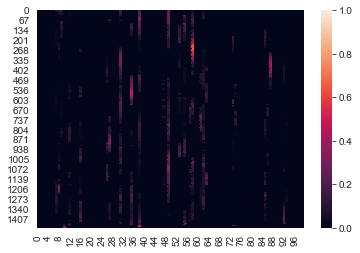


	Atlep1 recall manual model:


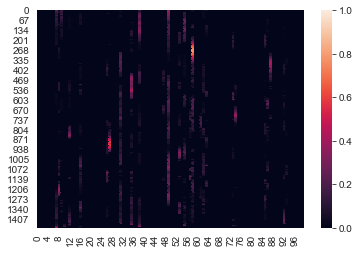


	Atlep1 recall auto model corrmat:


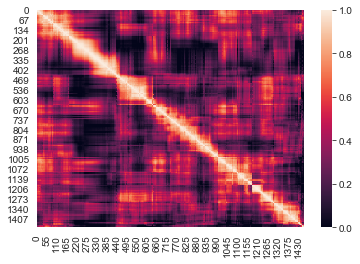


	Atlep1 recall manual model corrmat:


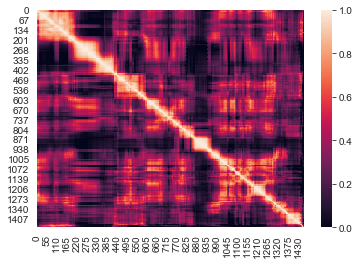


	Atlep1 recall automatic/episode model corrmat:


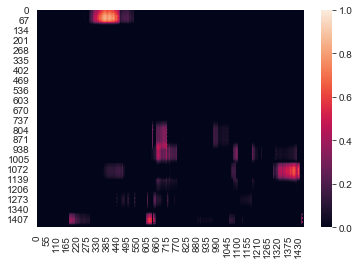


	Atlep1 recall manual/episode model corrmat:


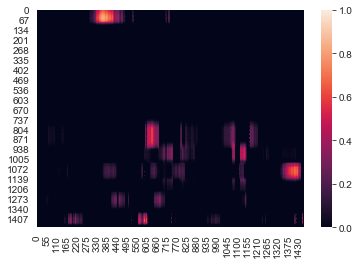

MD-013119-A-02, session 2, delayed

	Delayed recall auto model:


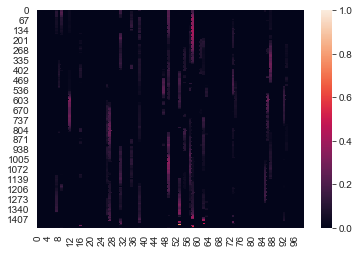


	Delayed recall manual model:


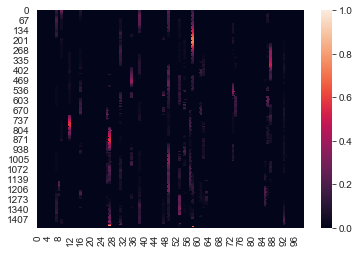


	Delayed recall auto model corrmat:


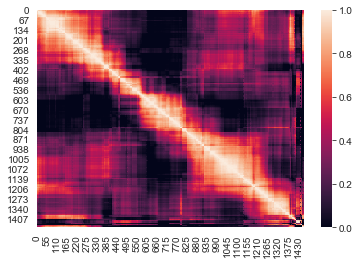


	Delayed recall manual model corrmat:


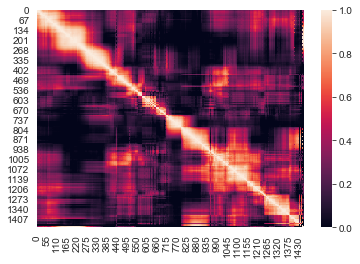


	Delayed recall automatic/episode model corrmat:


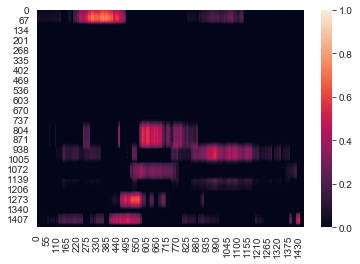


	Delayed recall manual/episode model corrmat:


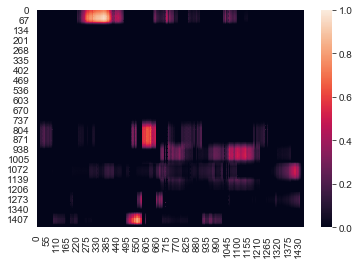

MD-013119-A-02, session 2, recall

	Atlep2 recall auto model:


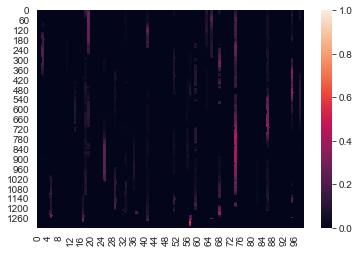


	Atlep2 recall manual model:


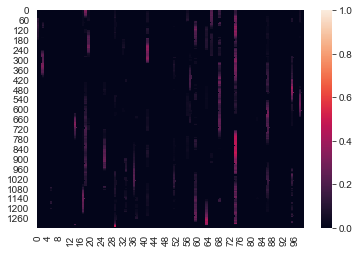


	Atlep2 recall auto model corrmat:


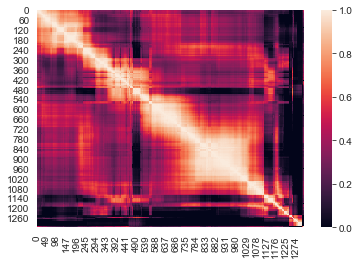


	Atlep2 recall manual model corrmat:


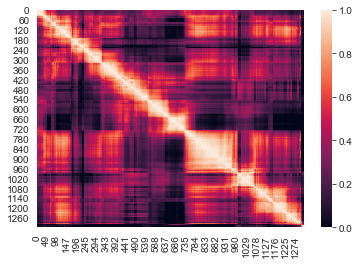


	Atlep2 recall automatic/episode model corrmat:


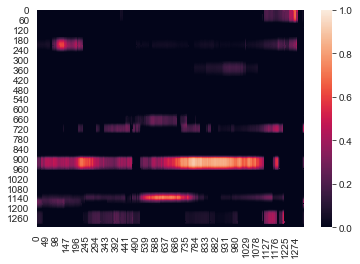


	Atlep2 recall manual/episode model corrmat:


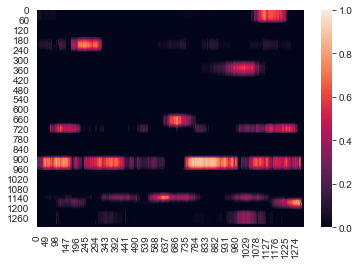

MD-102218-A-07, session 1, recall

	Atlep1 recall auto model:


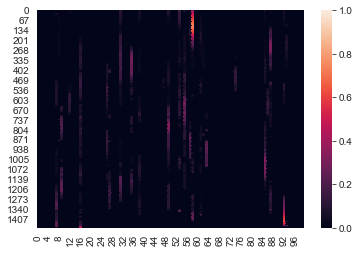


	Atlep1 recall manual model:


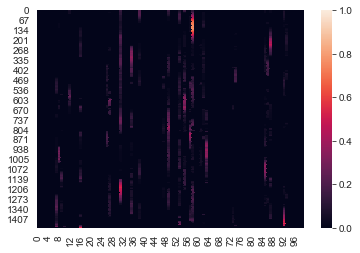


	Atlep1 recall auto model corrmat:


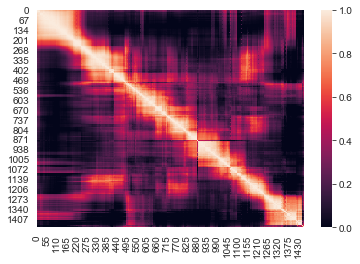


	Atlep1 recall manual model corrmat:


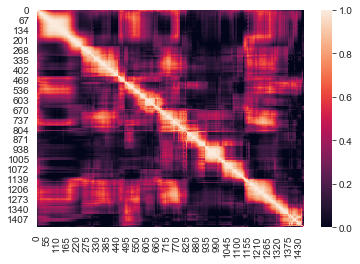


	Atlep1 recall automatic/episode model corrmat:


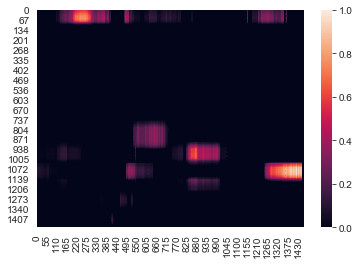


	Atlep1 recall manual/episode model corrmat:


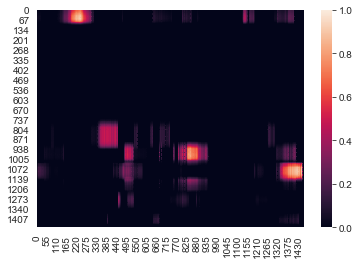

MD-102218-A-07, session 2, delayed

	Delayed recall auto model:


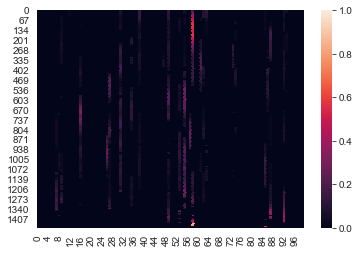


	Delayed recall manual model:


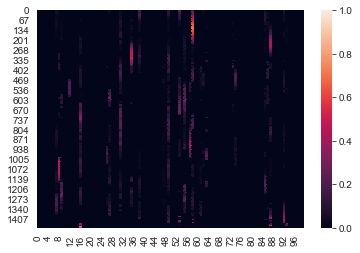


	Delayed recall auto model corrmat:


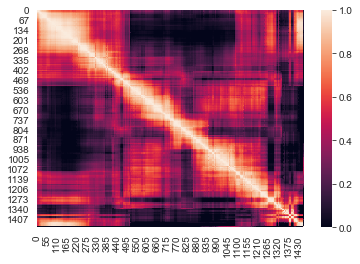


	Delayed recall manual model corrmat:


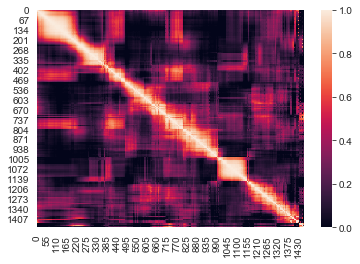


	Delayed recall automatic/episode model corrmat:


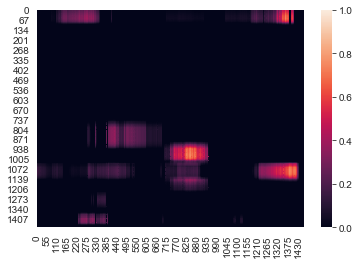


	Delayed recall manual/episode model corrmat:


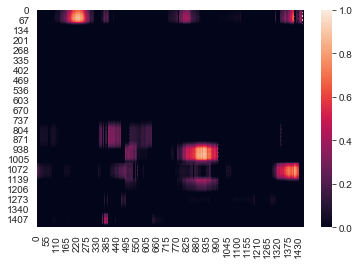

MD-102218-A-07, session 2, recall

	Atlep2 recall auto model:


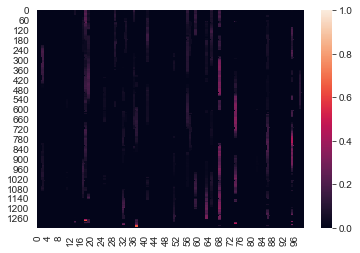


	Atlep2 recall manual model:


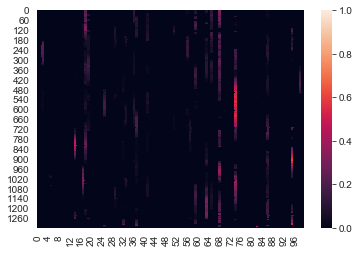


	Atlep2 recall auto model corrmat:


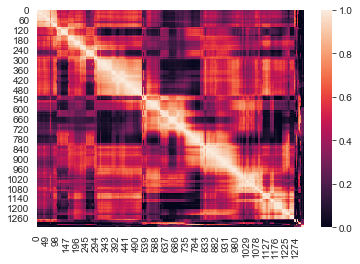


	Atlep2 recall manual model corrmat:


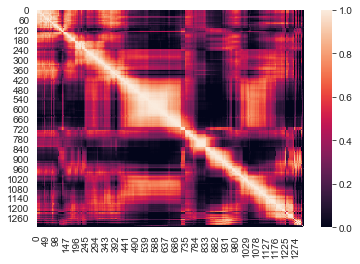


	Atlep2 recall automatic/episode model corrmat:


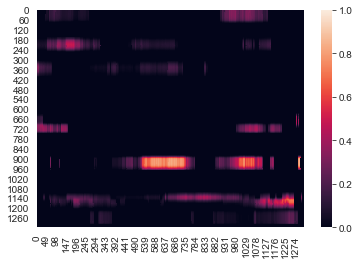


	Atlep2 recall manual/episode model corrmat:


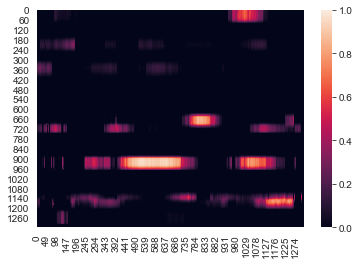

MD-020119-A-04, session 1, recall

	Atlep1 recall auto model:


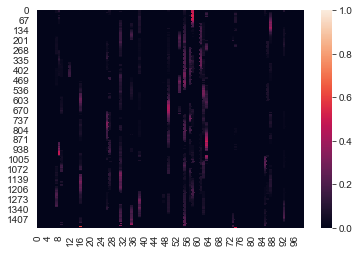


	Atlep1 recall manual model:


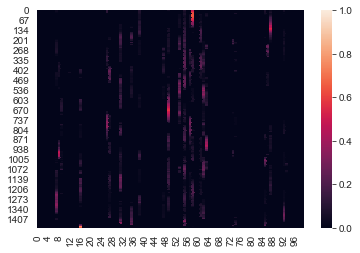


	Atlep1 recall auto model corrmat:


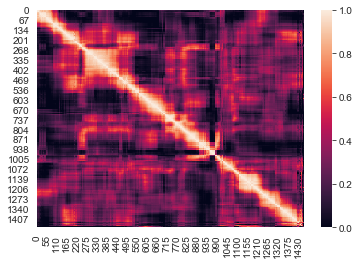


	Atlep1 recall manual model corrmat:


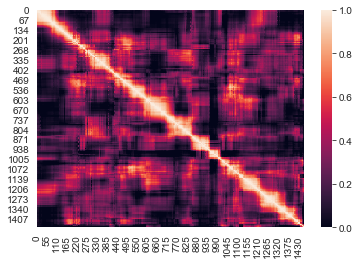


	Atlep1 recall automatic/episode model corrmat:


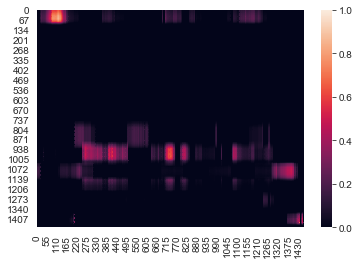


	Atlep1 recall manual/episode model corrmat:


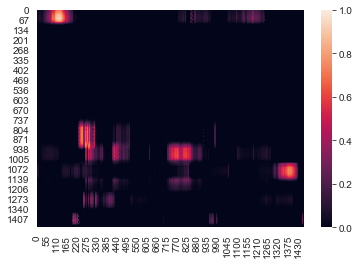

MD-020119-A-04, session 2, delayed

	Delayed recall auto model:


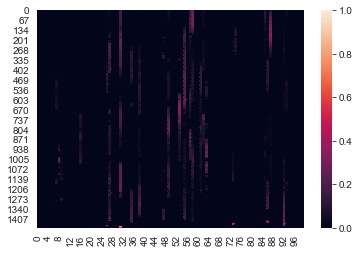


	Delayed recall manual model:


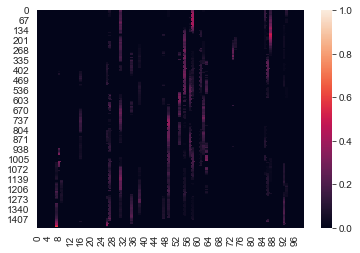


	Delayed recall auto model corrmat:


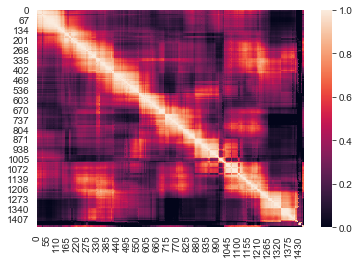


	Delayed recall manual model corrmat:


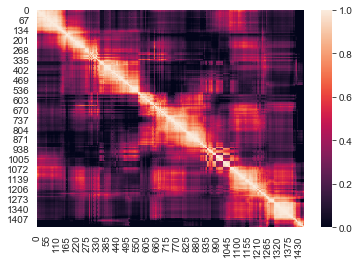


	Delayed recall automatic/episode model corrmat:


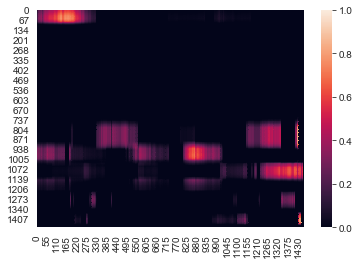


	Delayed recall manual/episode model corrmat:


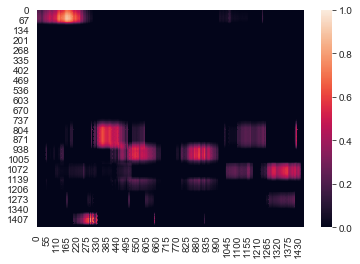

MD-020119-A-04, session 2, recall

	Atlep2 recall auto model:


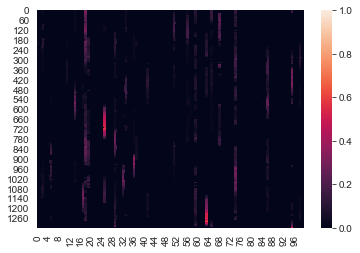


	Atlep2 recall manual model:


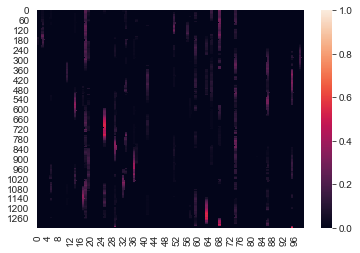


	Atlep2 recall auto model corrmat:


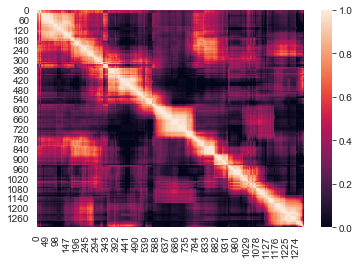


	Atlep2 recall manual model corrmat:


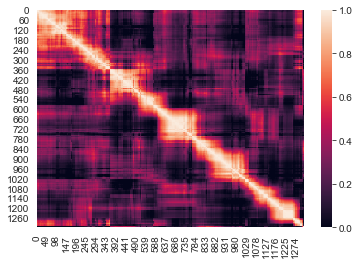


	Atlep2 recall automatic/episode model corrmat:


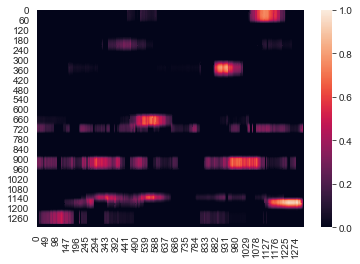


	Atlep2 recall manual/episode model corrmat:


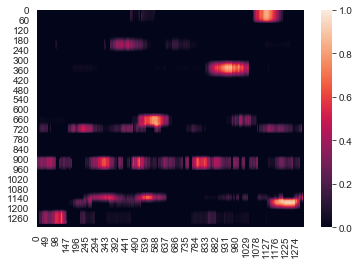

MD-102218-B-01, session 1, recall

	Atlep1 recall auto model:


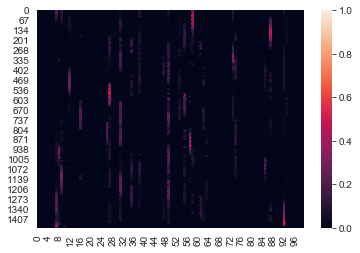


	Atlep1 recall manual model:


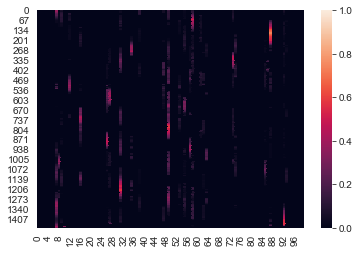


	Atlep1 recall auto model corrmat:


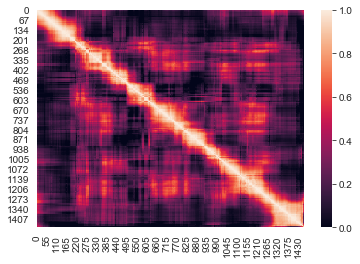


	Atlep1 recall manual model corrmat:


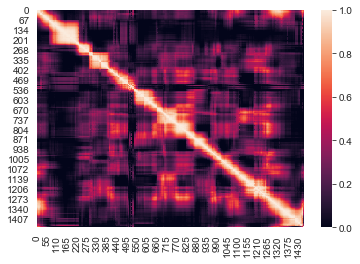


	Atlep1 recall automatic/episode model corrmat:


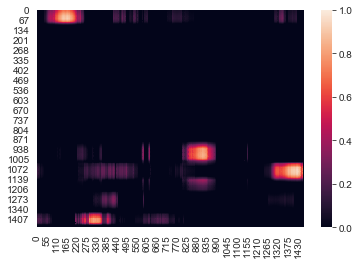


	Atlep1 recall manual/episode model corrmat:


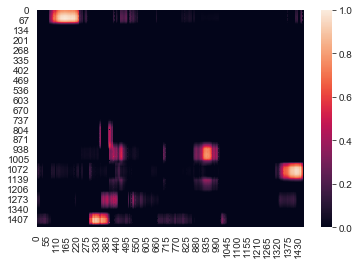

MD-102218-B-01, session 2, delayed

	Delayed recall auto model:


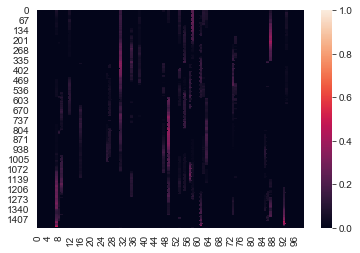


	Delayed recall manual model:


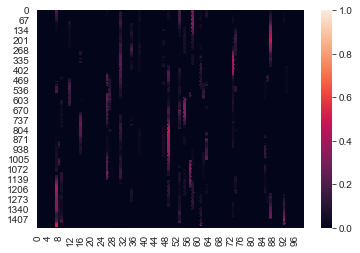


	Delayed recall auto model corrmat:


KeyboardInterrupt: 

In [30]:
for sid, data in rand5_turkids.items():
    for ses, tid in data.items():
        for rectype, transctype in recmod_dict_w200[tid].items():
            
            if rectype != 'prediction':
                print(sid+', '+ses+', '+rectype)

                if ses == 'session 1':
                    print('\n\tAtlep1 recall auto model:')
                    sns.heatmap(pd.DataFrame(transctype['automatic']), vmin=0, vmax=1)
                    plt.show()
                    print('\n\tAtlep1 recall manual model:')
                    sns.heatmap(pd.DataFrame(transctype['manual']), vmin=0, vmax=1)
                    plt.show()
                    print('\n\tAtlep1 recall auto model corrmat:')
                    sns.heatmap(pd.DataFrame(transctype['automatic']).T.corr(), vmin=0, vmax=1)
                    plt.show()
                    print('\n\tAtlep1 recall manual model corrmat:')
                    sns.heatmap(pd.DataFrame(transctype['manual']).T.corr(), vmin=0, vmax=1)
                    plt.show()
                    print('\n\tAtlep1 recall automatic/episode model corrmat:')
                    sns.heatmap(1-cdist(atlep1_model, transctype['automatic'], 'correlation'), vmin=0, vmax=1)
                    plt.show()
                    print('\n\tAtlep1 recall manual/episode model corrmat:')
                    sns.heatmap(1-cdist(atlep1_model, transctype['manual'], 'correlation'), vmin=0, vmax=1)
                    plt.show()
                    
                elif rectype == 'delayed':
                    print('\n\tDelayed recall auto model:')
                    sns.heatmap(pd.DataFrame(transctype['automatic']), vmin=0, vmax=1)
                    plt.show()
                    print('\n\tDelayed recall manual model:')
                    sns.heatmap(pd.DataFrame(transctype['manual']), vmin=0, vmax=1)
                    plt.show()
                    print('\n\tDelayed recall auto model corrmat:')
                    sns.heatmap(pd.DataFrame(transctype['automatic']).T.corr(), vmin=0, vmax=1)
                    plt.show()
                    print('\n\tDelayed recall manual model corrmat:')
                    sns.heatmap(pd.DataFrame(transctype['manual']).T.corr(), vmin=0, vmax=1)
                    plt.show()
                    print('\n\tDelayed recall automatic/episode model corrmat:')
                    sns.heatmap(1-cdist(atlep1_model, transctype['automatic'], 'correlation'), vmin=0, vmax=1)
                    plt.show()
                    print('\n\tDelayed recall manual/episode model corrmat:')
                    sns.heatmap(1-cdist(atlep1_model, transctype['manual'], 'correlation'), vmin=0, vmax=1)
                    plt.show()
                    
                    
                elif 'A' in sid:
                    print('\n\tAtlep2 recall auto model:')
                    sns.heatmap(pd.DataFrame(transctype['automatic']), vmin=0, vmax=1)
                    plt.show()
                    print('\n\tAtlep2 recall manual model:')
                    sns.heatmap(pd.DataFrame(transctype['manual']), vmin=0, vmax=1)
                    plt.show()
                    print('\n\tAtlep2 recall auto model corrmat:')
                    sns.heatmap(pd.DataFrame(transctype['automatic']).T.corr(), vmin=0, vmax=1)
                    plt.show()
                    print('\n\tAtlep2 recall manual model corrmat:')
                    sns.heatmap(pd.DataFrame(transctype['manual']).T.corr(), vmin=0, vmax=1)
                    plt.show()
                    print('\n\tAtlep2 recall automatic/episode model corrmat:')
                    sns.heatmap(1-cdist(atlep2_model, transctype['automatic'], 'correlation'), vmin=0, vmax=1)
                    plt.show()
                    print('\n\tAtlep2 recall manual/episode model corrmat:')
                    sns.heatmap(1-cdist(atlep2_model, transctype['manual'], 'correlation'), vmin=0, vmax=1)
                    plt.show()
                    
                    
                else:
                    print('\n\tArrdev recall auto model:')
                    sns.heatmap(pd.DataFrame(transctype['automatic']), vmin=0, vmax=1)
                    plt.show()
                    print('\n\tArrdev recall manual model:')
                    sns.heatmap(pd.DataFrame(transctype['manual']), vmin=0, vmax=1)
                    plt.show()
                    print('\n\tArrdev recall auto model corrmat:')
                    sns.heatmap(pd.DataFrame(transctype['automatic']).T.corr(), vmin=0, vmax=1)
                    plt.show()
                    print('\n\tArrdev recall manual model corrmat:')
                    sns.heatmap(pd.DataFrame(transctype['manual']).T.corr(), vmin=0, vmax=1)
                    plt.show()
                    print('\n\tArrdev recall automatic/episode model corrmat:')
                    sns.heatmap(1-cdist(arrdev_model, transctype['automatic'], 'correlation'), vmin=0, vmax=1)
                    plt.show()
                    print('\n\tArrdev recall manual/episode model corrmat:')
                    sns.heatmap(1-cdist(arrdev_model, transctype['manual'], 'correlation'), vmin=0, vmax=1)
                    plt.show()
                    

In [68]:
autos = []
mans = []

for turkid, data in recmod_dict_w200.items():
    if 'delayed' in data.keys():
        if np.shape(data['recall']['automatic']) != (1317, 100):
            autos.append(data['recall']['automatic'])
            mans.append(data['recall']['manual'])

In [69]:
avgauto = np.mean(autos, axis=0)
avgman = np.mean(mans, axis=0)

In [62]:
avgauto

array([[ 0.00037495,  0.00037495,  0.0785695 , ...,  0.00037495,
         0.02541135,  0.00037495],
       [-0.00020999, -0.00020999,  0.08253032, ..., -0.00020999,
         0.02598669, -0.00020999],
       [ 0.00051947,  0.00051947,  0.07981576, ...,  0.00051947,
         0.02287767,  0.00051947],
       ...,
       [ 0.0061814 ,  0.0061814 ,  0.00819373, ...,  0.0061814 ,
         0.00795331,  0.0061814 ],
       [ 0.00889974,  0.00889974,  0.00683735, ...,  0.00889974,
         0.00569198,  0.00889974],
       [ 0.00763431,  0.00763431,  0.00967902, ...,  0.00763431,
         0.01236464,  0.00763431]])

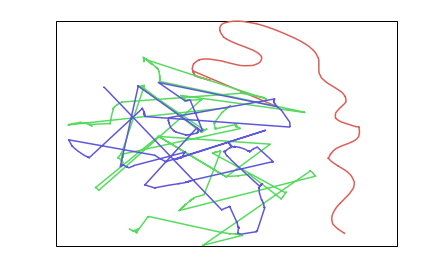

In [71]:
hyp.plot([arrdev_model]+[avgauto]+[avgman], reduce='UMAP', ndims=2)

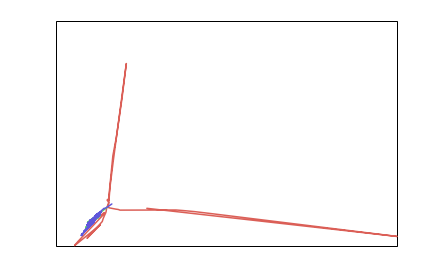

In [72]:
hyp.plot([arrdev_model]+[avgauto]+[avgman], ndims=2)

In [63]:
np.shape(atlep2_model)

(1317, 100)

In [36]:
atlep1_model

array([[8.08430468e-06, 8.08430468e-06, 8.08430468e-06, ...,
        8.08430468e-06, 8.08430468e-06, 8.08430468e-06],
       [8.11083060e-06, 8.11083060e-06, 8.11083060e-06, ...,
        8.11083060e-06, 8.11083060e-06, 8.11083060e-06],
       [8.13735652e-06, 8.13735652e-06, 8.13735652e-06, ...,
        8.13735652e-06, 8.13735652e-06, 8.13735652e-06],
       ...,
       [5.48807917e-04, 5.48807917e-04, 5.48807917e-04, ...,
        5.48807917e-04, 5.48807917e-04, 7.71047185e-01],
       [7.23746689e-04, 7.23746689e-04, 7.23746689e-04, ...,
        7.23746689e-04, 7.23746689e-04, 5.82531354e-01],
       [8.98685460e-04, 8.98685460e-04, 8.98685460e-04, ...,
        8.98685460e-04, 8.98685460e-04, 3.94015523e-01]])

In [74]:
len([i for i in np.var(atlep1_model, axis=0) if i > 0.000001])

16

In [52]:
len([i for i in np.var(atlep2_model, axis=0) if i > 0.001])

23

In [53]:
len([i for i in np.var(arrdev_model, axis=0) if i > 0.001])

25